In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sorted_portfolios import get_sorted_index, get_sorted_portfolio
from utils import *
from signals import *
from visualization import plot_group_cum, plot_solo_cum

plt.style.use("default")
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Read Data

In [128]:
# CRSP data
crsp = pd.read_csv("csrp_msf.csv", index_col=0)
crsp['date'] = pd.to_datetime(crsp.date)
# Construct dfs
dfs = {}
dfs['prc'] = np.abs(date_cusip_pivot(crsp, 'prc_adj'))
dfs['ret'] = get_simple_ret(dfs['prc'])
dfs['idx_vol_threshold'] = get_volume_threshold(date_cusip_pivot(crsp, "vol"))

In [129]:
idx_june = dfs['ret'].index.month == 6
idx_Q = idx_june.copy()
for month in [3, 9, 12]:
    idx_Q = idx_Q | (dfs['ret'].index.month == month)

In [130]:
comp_funq = pd.read_csv("comp_fundq.csv", index_col=0).rename(columns={"datadate": "date"})
comp_funq['cusip'] = comp_funq['cusip'].apply(lambda x: str(x)[:8])
# comp_funq = comp_funq[comp_funq.datafmt == 'STD']
# comp_funq = comp_funq[~(comp_funq.cusip == "nan")].reset_index(drop=True)
comp_funq['date'] = pd.to_datetime(comp_funq.date)
comp_funq.reset_index(drop=True, inplace=True) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_17672\1033742287.py:1: DtypeWarning: Columns (11,13,14,18,19,21,26,27,31,33,34,35,36,635) have mixed types. Specify dtype option on import or set low_memory=False.
  comp_funq = pd.read_csv("comp_fundq.csv", index_col=0).rename(columns={"datadate": "date"})


In [131]:
df_size = get_size_df(crsp)
df_size[~idx_june] = np.nan

In [132]:
size_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_size * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.20),
        #quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        )
)

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


In [133]:
def process_ff(df):
    df = df / 100
    # Convert index
    df.index = df.index.to_series().apply(lambda x: pd.to_datetime(f"{str(x)[:4]}-{str(x)[4:]}-01") + pd.offsets.MonthEnd(0))
    return df

def ls(df, l, s):
    return df.iloc[:, l] - df.iloc[:, s]

In [134]:
ff_size = process_ff(pd.read_csv('Portfolios_Formed_on_ME.CSV', index_col=0))
#ff_size = ff_size.iloc[:, 4:9]
ff_size = ff_size.iloc[:, 9:]

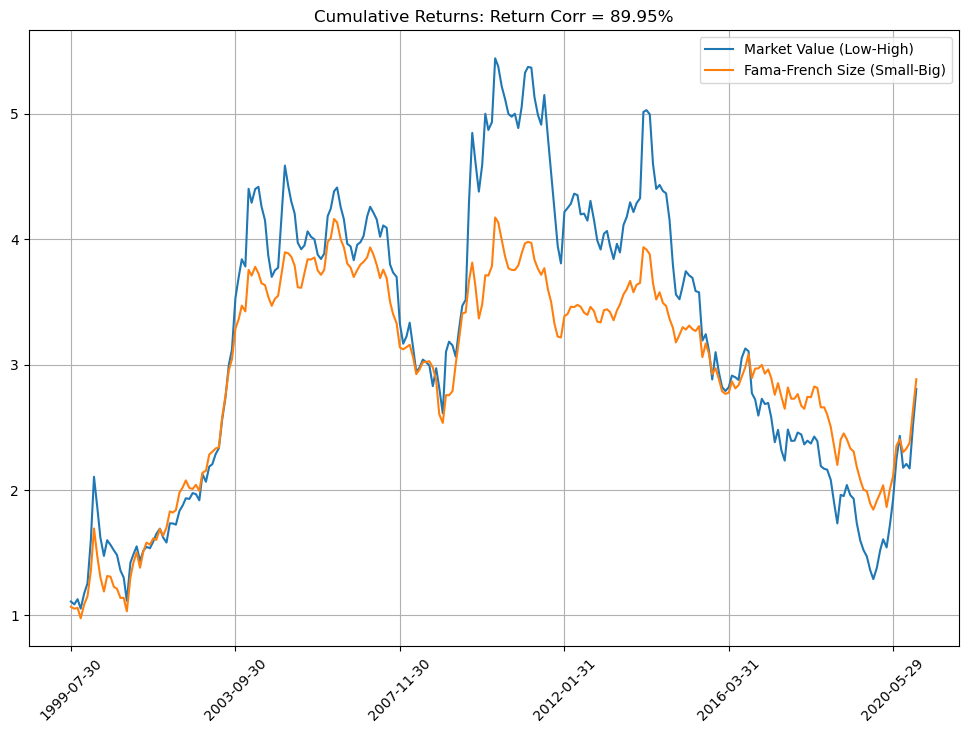

In [135]:
start = (1999, 7, 1)
end = (2020, 12, 31)
temp = filter_datetime_df(size_portfolio, start, end)
temp_ff = filter_datetime_df(ff_size, start, end)
plt.figure(figsize=(12, 8))

plt.plot(temp.index, (1+ls(temp, 0, -1)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp.index, (1+ls(temp_ff, 0, -1)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
# plt.plot(temp.index, (1+temp.iloc[:, 0]).to_numpy().cumprod(), label='Small')
# plt.plot(temp.index, (1+temp_ff.iloc[:, 0]).to_numpy().cumprod(), label='FF Small')
# plt.plot(temp.index, (1+temp.iloc[:, -1]).to_numpy().cumprod(), '--', label='Big')
# plt.plot(temp.index, (1+temp_ff.iloc[:,-1]).to_numpy().cumprod(), '--', label='FF Big')
corr = np.corrcoef([ls(temp, 0, -1), ls(temp_ff, 0, -1)])[0, 1]
plt.legend(loc='upper right')
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.xticks(temp.index[::50], rotation=45)
plt.show()

In [136]:
ff_mom = pd.read_excel("french_mom_ew.xlsx", index_col=0)
ff_mom = process_ff(ff_mom)

In [137]:
df_mom = get_momentum(dfs['ret'])

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


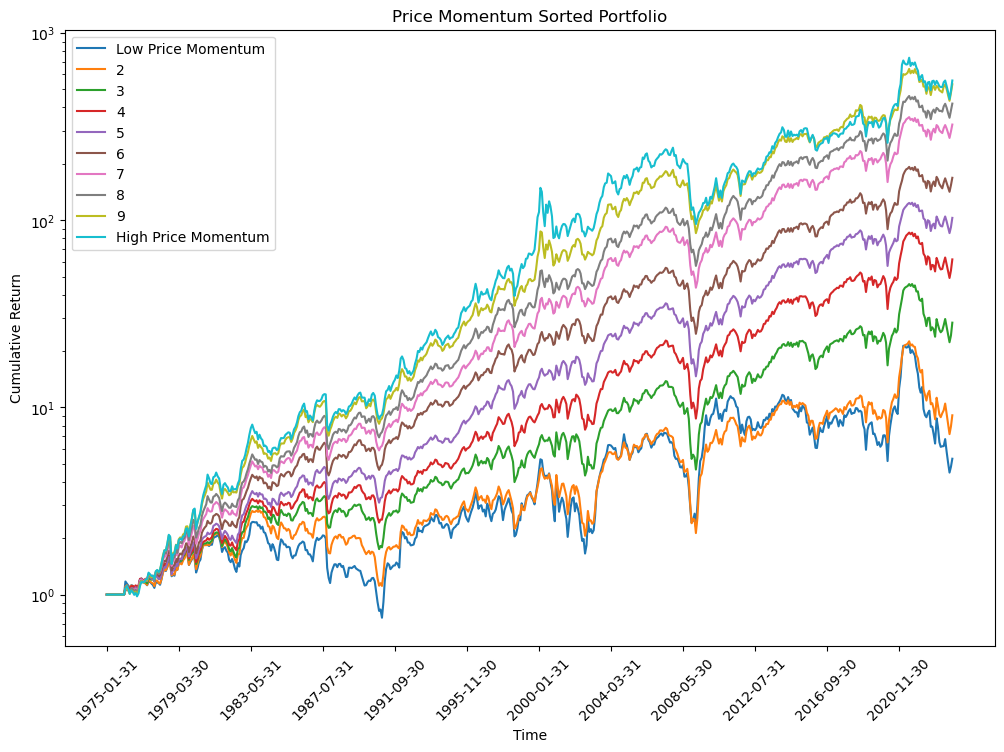

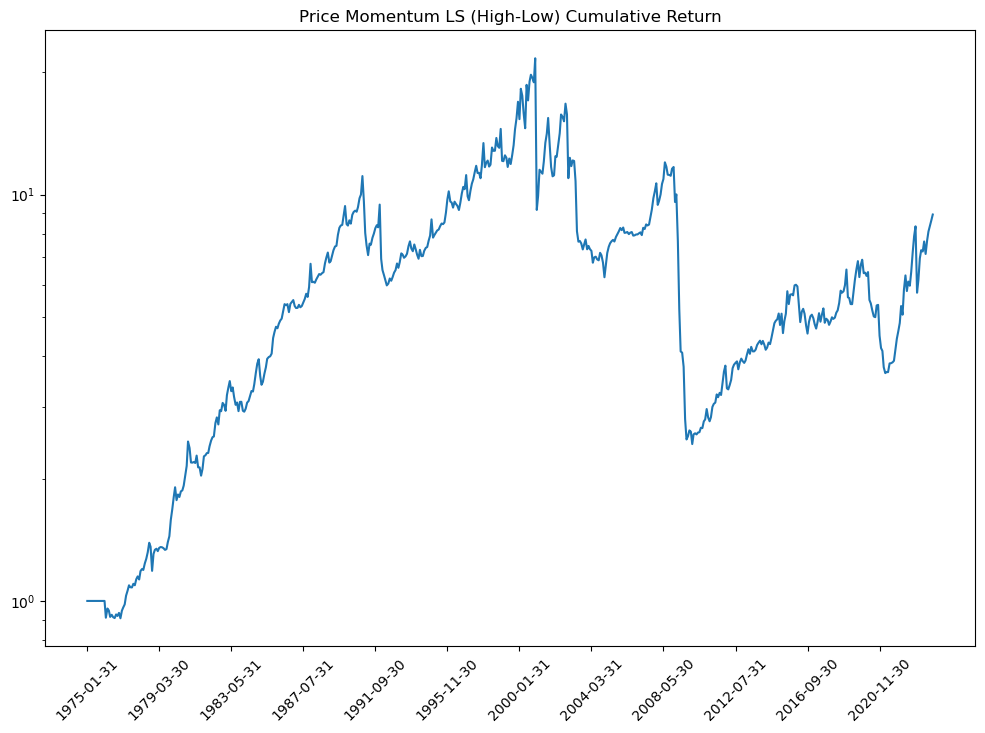

In [154]:
price_momentum = df_mom.copy(deep=True)
price_momentum[~idx_Q] = np.nan
mom_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        df_mom * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.2),
        holding_period=3
        #quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        )
)
plot_group_cum(mom_portfolio, "Price Momentum")
plot_solo_cum(ls(mom_portfolio, -1, 0), "Price Momentum LS (High-Low) Cumulative Return")

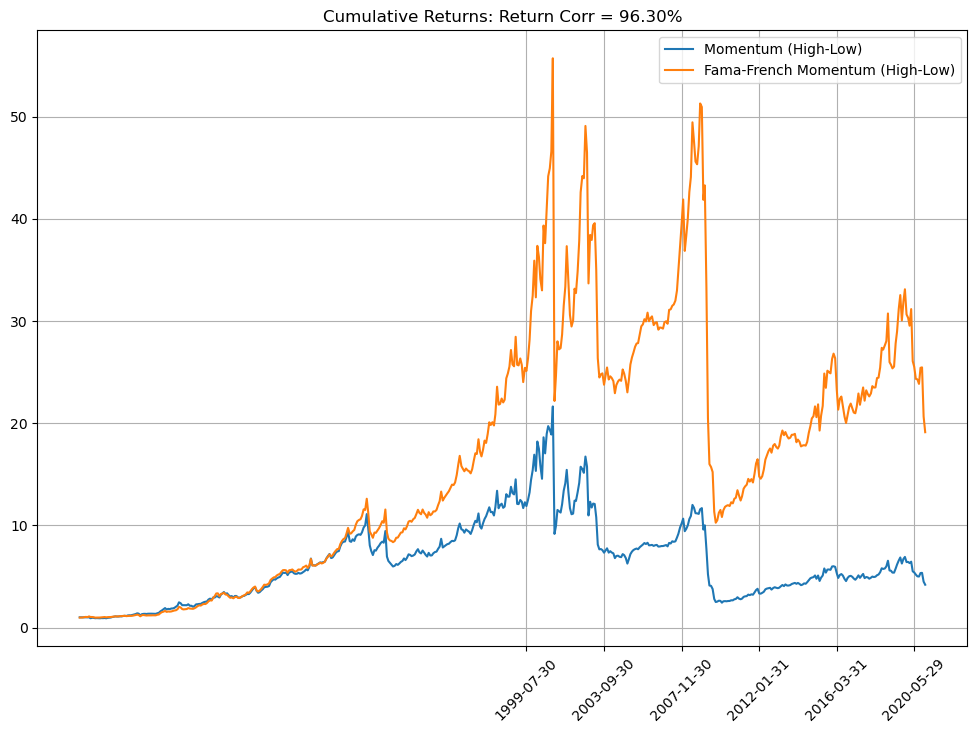

In [139]:
start = (1975, 7, 1)
end = (2020, 12, 31)
temp_mom = filter_datetime_df(mom_portfolio, start, end)
temp_mom_ff = filter_datetime_df(ff_mom, start, end)
plt.figure(figsize=(12, 8))

plt.plot(temp_mom.index, (1+ls(temp_mom, -1, 0)).to_numpy().cumprod(), label='Momentum (High-Low)')
plt.plot(temp_mom.index, (1+ls(temp_mom_ff, -1, 0)).to_numpy().cumprod(), label='Fama-French Momentum (High-Low)')
# plt.plot(temp_mom.index, (1+temp_mom.iloc[:, 0]).to_numpy().cumprod(), label='Small')
# plt.plot(temp_mom.index, (1+temp_mom_ff.iloc[:, 0]).to_numpy().cumprod(), label='FF Small')
# plt.plot(temp_mom.index, (1+temp_mom.iloc[:, -1]).to_numpy().cumprod(), '--', label='Big')
# plt.plot(temp_mom.index, (1+temp_mom_ff.iloc[:,-1]).to_numpy().cumprod(), '--', label='FF Big')
corr = np.corrcoef([ls(temp_mom, 0, -1), ls(temp_mom_ff, 0, -1)])[0, 1]
plt.legend(loc='upper right')
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.xticks(temp.index[::50], rotation=45)
plt.grid()
plt.show()

# Size

In [140]:
size = comp_funq["date cusip mkvaltq consol".split()]
size['size'] = size.eval("mkvaltq")
size = get_non_duplicated_df(size, "size")
size = date_cusip_pivot(size, "size").reindex(columns=dfs['ret'].columns)
size = get_time_merge(size, dfs['ret'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_17672\3164720465.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  size['size'] = size.eval("mkvaltq")
c:\Users\Admin\Documents\GitHub\Capstone\code\utils.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp = temp[~((temp.duplicated(subset=['date', 'cusip'], keep=False)) & (df[val].isna()))]


c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


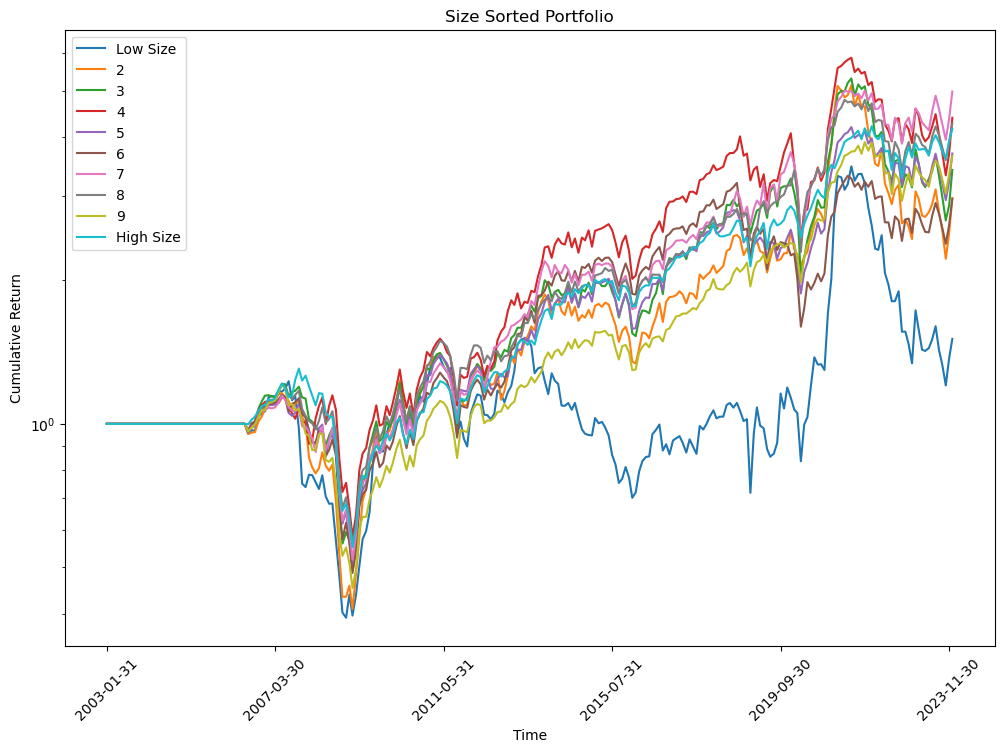

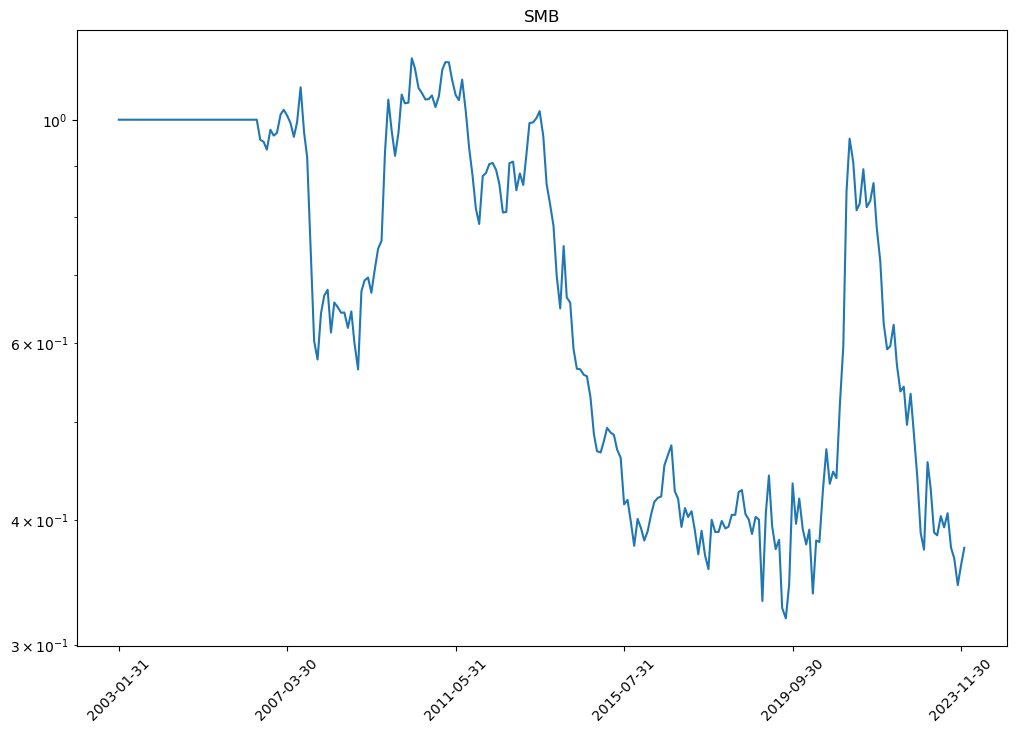

In [150]:
size_v1 = size.copy(deep=True)
size_v1[~idx_june] = np.nan
size_port1 = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        size_v1 * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.2),
        holding_period=12
        #,quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        #,quantiles=np.array([.3, .7])
        )
)
size_port1 = filter_datetime_df(size_port1, (2003, 1, 1), (2023, 12, 31))
plot_group_cum(size_port1, "Size")
plot_solo_cum(ls(size_port1, 0, -1), "SMB")

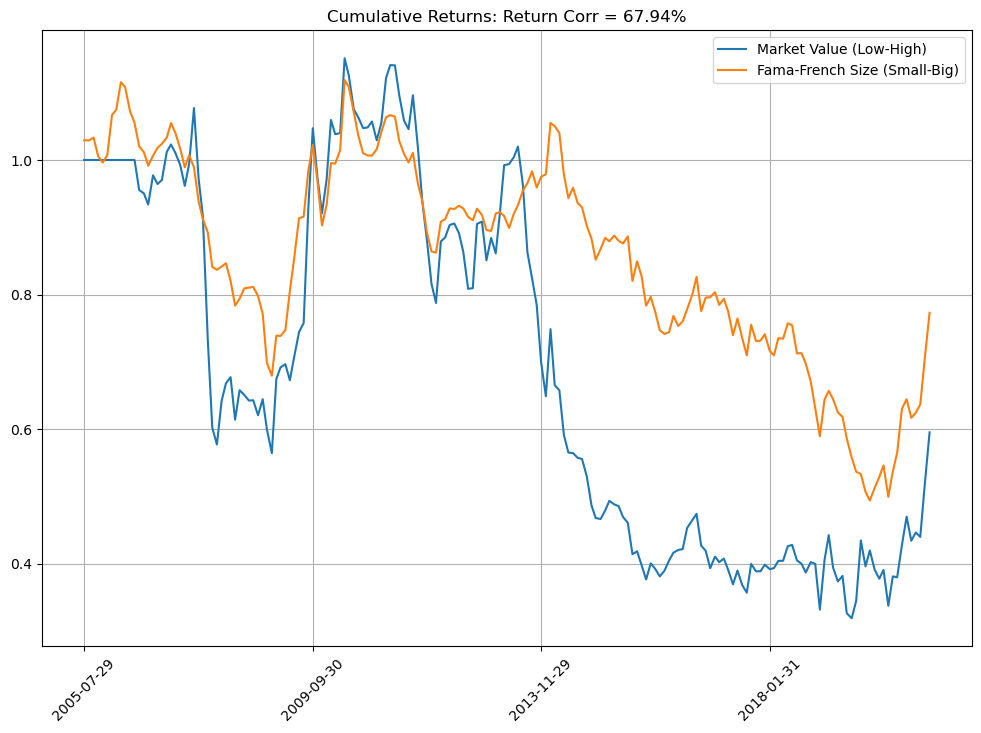

In [151]:
start = (2005, 7, 1)
end = (2020, 12, 31)
temp = filter_datetime_df(size_port1, start, end)
temp_ff = filter_datetime_df(ff_size, start, end)
plt.figure(figsize=(12, 8))

plt.plot(temp.index, (1+ls(temp, 0, -1)).to_numpy().cumprod(), label='Market Value (Low-High)')
plt.plot(temp.index, (1+ls(temp_ff, 0, -1)).to_numpy().cumprod(), label='Fama-French Size (Small-Big)')
# plt.plot(temp.index, (1+temp.iloc[:, 0]).to_numpy().cumprod(), label='Small')
# plt.plot(temp.index, (1+temp_ff.iloc[:, 0]).to_numpy().cumprod(), label='FF Small')
# plt.plot(temp.index, (1+temp.iloc[:, -1]).to_numpy().cumprod(), '--', label='Big')
# plt.plot(temp.index, (1+temp_ff.iloc[:,-1]).to_numpy().cumprod(), '--', label='FF Big')
corr = np.corrcoef([ls(temp, 0, -1), ls(temp_ff, 0, -1)])[0, 1]
plt.legend(loc='upper right')
plt.title(f"Cumulative Returns: Return Corr = {corr:.2%}")
plt.grid()
plt.xticks(temp.index[::50], rotation=45)
plt.show()

# EPS

In [143]:
eps = comp_funq["date cusip epspxq consol".split()]
eps['eps'] = eps.eval("epspxq")
eps = get_non_duplicated_df(eps, "eps")
eps = date_cusip_pivot(eps, "eps").reindex(columns=dfs['ret'].columns)
eps = get_time_merge(eps, dfs['ret'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_17672\3728642897.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eps['eps'] = eps.eval("epspxq")
c:\Users\Admin\Documents\GitHub\Capstone\code\utils.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp = temp[~((temp.duplicated(subset=['date', 'cusip'], keep=False)) & (df[val].isna()))]


c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


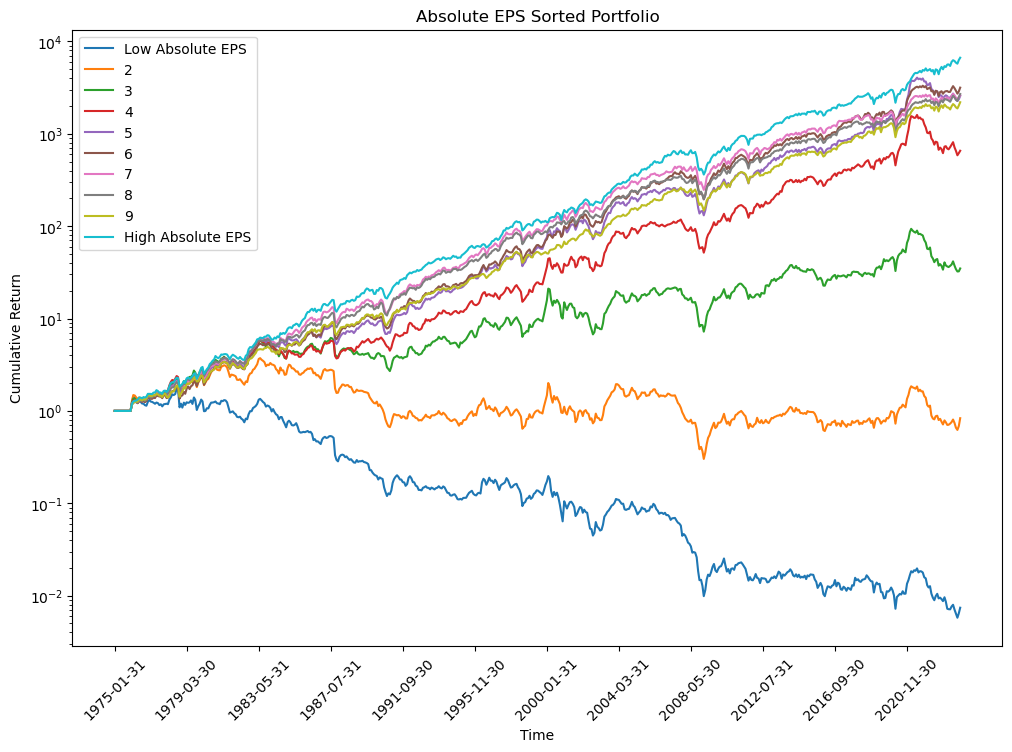

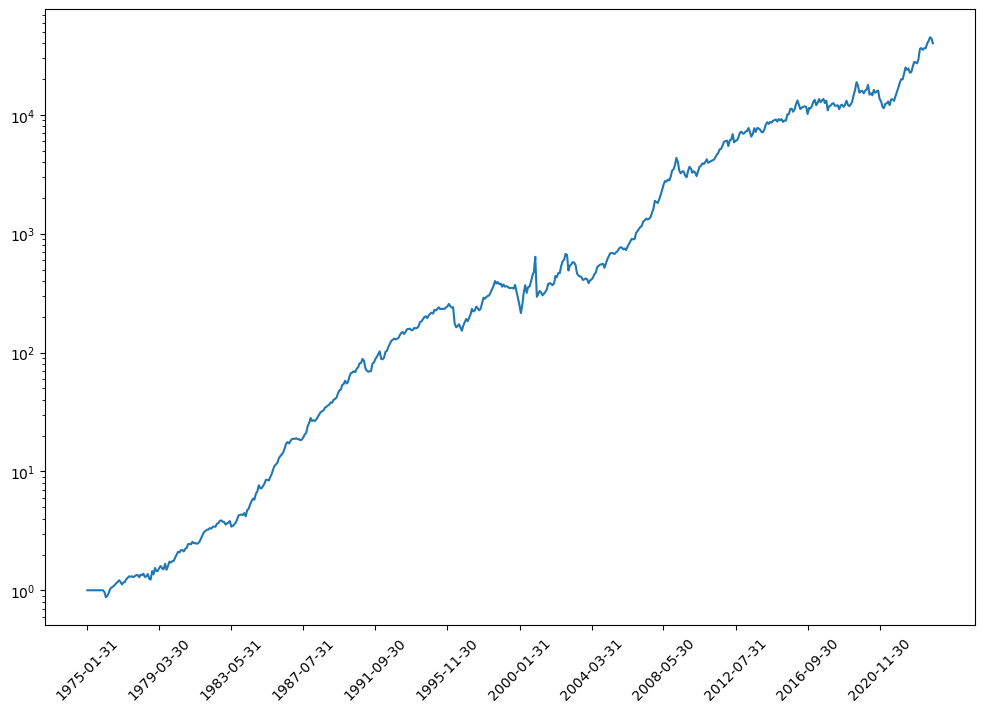

In [144]:
eps_v1 = eps.copy(deep=True)
eps_v1[~idx_Q] = np.nan
eps_portfolio1 = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        eps_v1 * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.2),
        holding_period=3
        #,quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        #,quantiles=np.array([.3, .7])
        )
)
plot_group_cum(eps_portfolio1, "Absolute EPS")
plot_solo_cum(ls(eps_portfolio1, -1, 0))

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


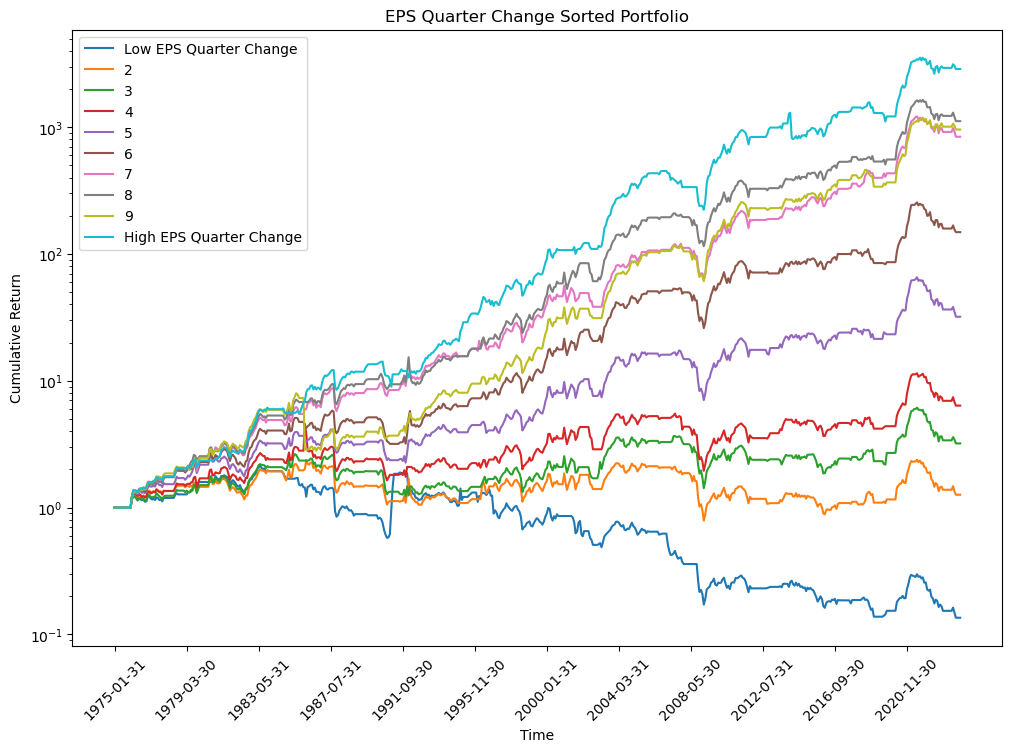

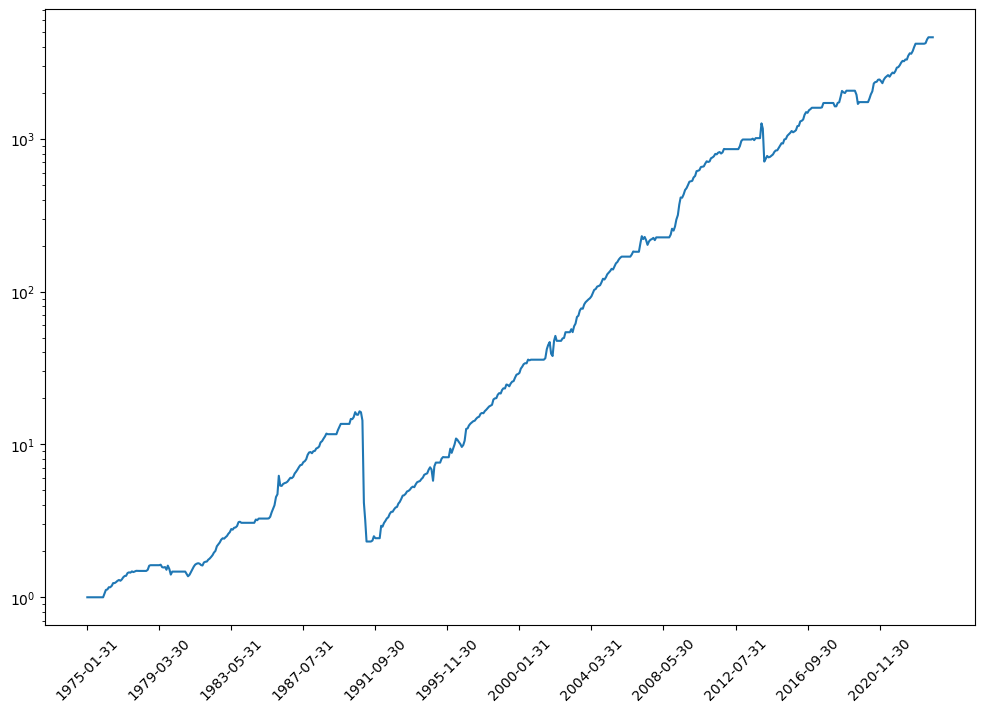

In [145]:
eps_v2 = eps.copy(deep=True)
eps_v2[~idx_Q] = np.nan
eps_v2 = eps_v2.diff(3) / eps_v2.rolling(window=24, min_periods=4).std()
eps_portfolio2 = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        eps_v2 * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.20),
        holding_period=3
        #,quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        #,quantiles=np.array([.3, .7])
        )
)
plot_group_cum(eps_portfolio2, "EPS Quarter Change")
plot_solo_cum(ls(eps_portfolio2, -1, 0))

# PM

In [146]:
pm = comp_funq["date cusip niq saleq consol".split()]
pm['pm'] = pm.eval("niq/saleq")
pm = get_non_duplicated_df(pm, "pm")
pm = date_cusip_pivot(pm, "pm").reindex(columns=dfs['ret'].columns)
pm = get_time_merge(pm, dfs['ret'])

C:\Users\Admin\AppData\Local\Temp\ipykernel_17672\3076592829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pm['pm'] = pm.eval("niq/saleq")
c:\Users\Admin\Documents\GitHub\Capstone\code\utils.py:57: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  temp = temp[~((temp.duplicated(subset=['date', 'cusip'], keep=False)) & (df[val].isna()))]


c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


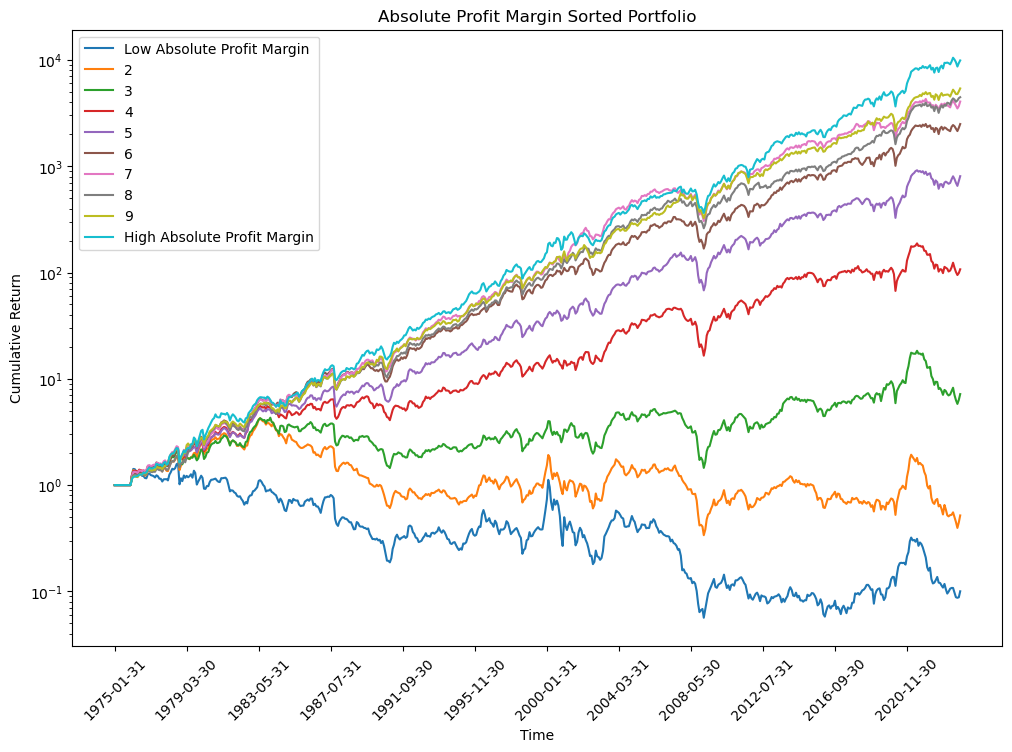

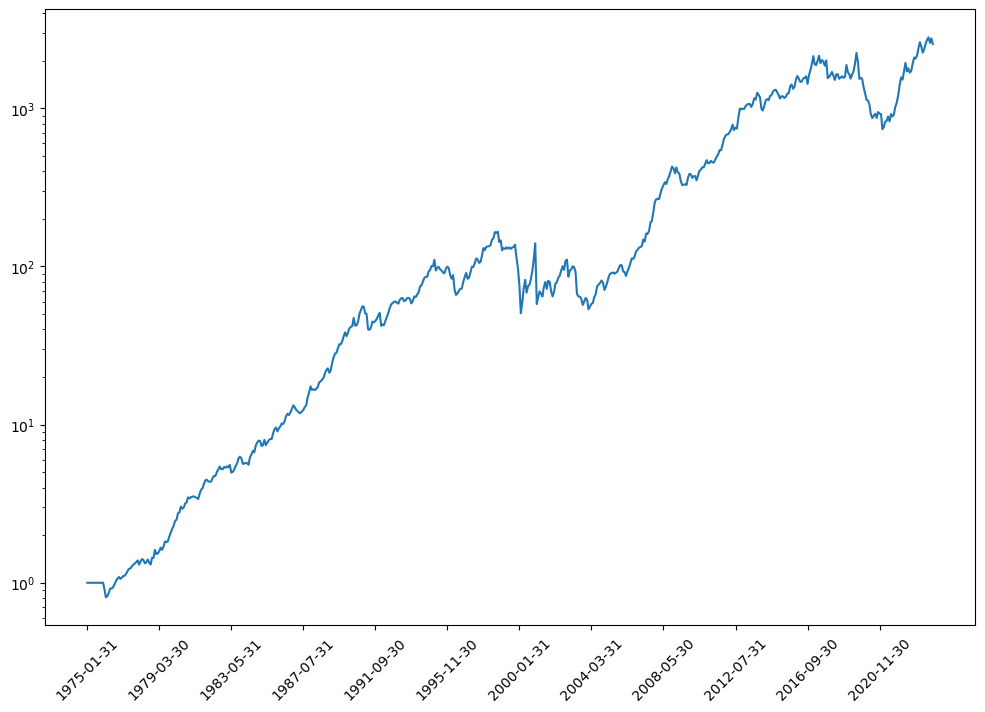

In [147]:
pm_v1 = pm.copy(deep=True)
pm_v1[~idx_Q] = np.nan
pm_portfolio = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        pm_v1 * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.2),
        holding_period=3
        #,quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        #,quantiles=np.array([.3, .7])
        )
)
plot_group_cum(pm_portfolio, "Absolute Profit Margin")
plot_solo_cum(ls(pm_portfolio, -1, 0))

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


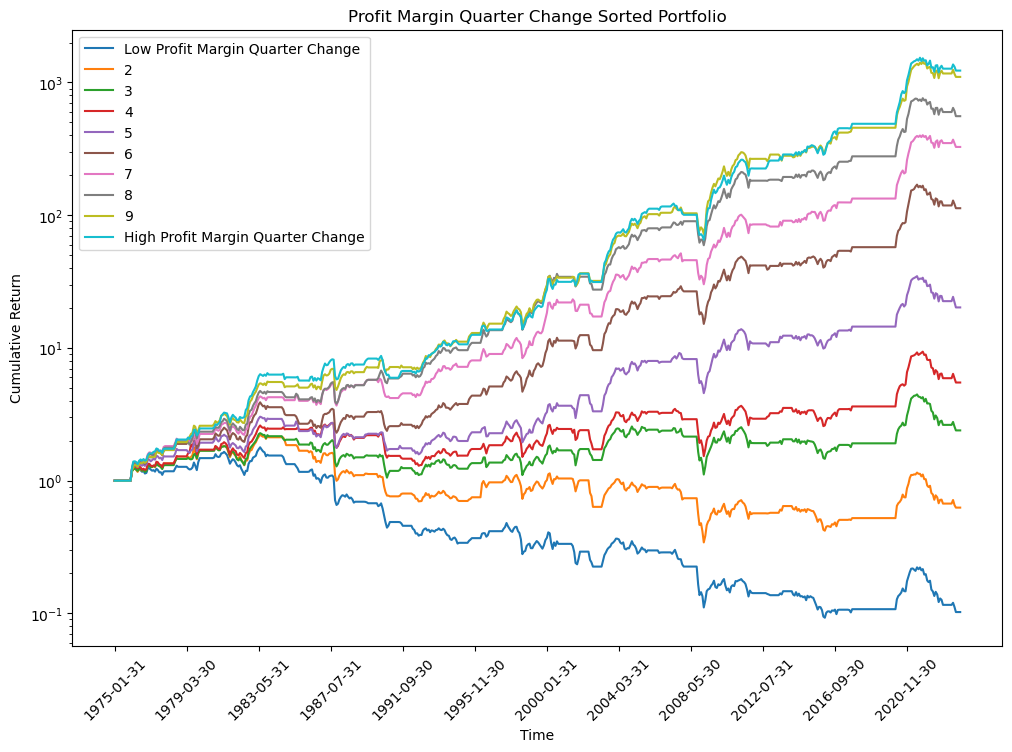

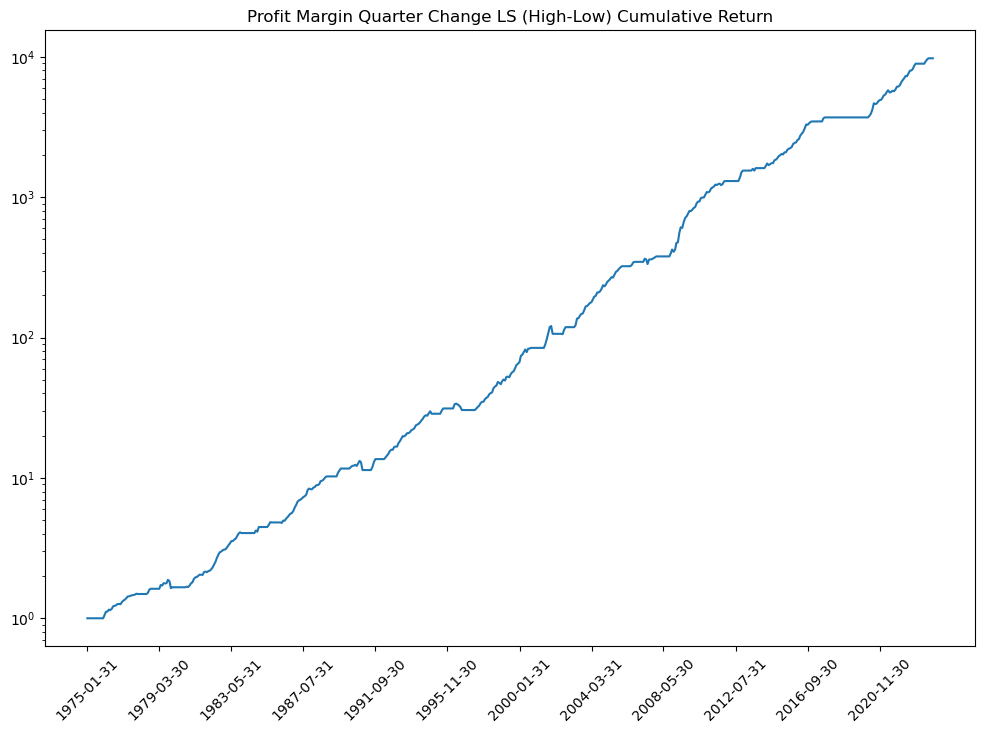

In [148]:
pm_v2 = pm.copy(deep=True)
pm_v2[~idx_Q] = np.nan
pm_v2 = pm_v2.diff(3) / pm_v2.rolling(window=18, min_periods=4).std()
pm_v2[count_non_cols(pm_v2) < 100] = np.nan
pm_portfolio2 = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        pm_v2 * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.2),
        holding_period=3
        #,quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        #,quantiles=np.array([.3, .7])
        )
)
plot_group_cum(pm_portfolio2, "Profit Margin Quarter Change")
plot_solo_cum(ls(pm_portfolio2, -1, 0), "Profit Margin Quarter Change LS (High-Low) Cumulative Return")

c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,
c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4658: RuntimeWarning: invalid value encountered in subtract
  subtract(b, diff_b_a * (1 - t), out=lerp_interpolation, where=t >= 0.5,
c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4657: RuntimeWarning: invalid value encountered in add
  lerp_interpolation = asanyarray(add(a, diff_b_a * t, out=out))
c:\Users\Admin\anaconda3\Lib\site-packages\numpy\lib\function_base.py:4655: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


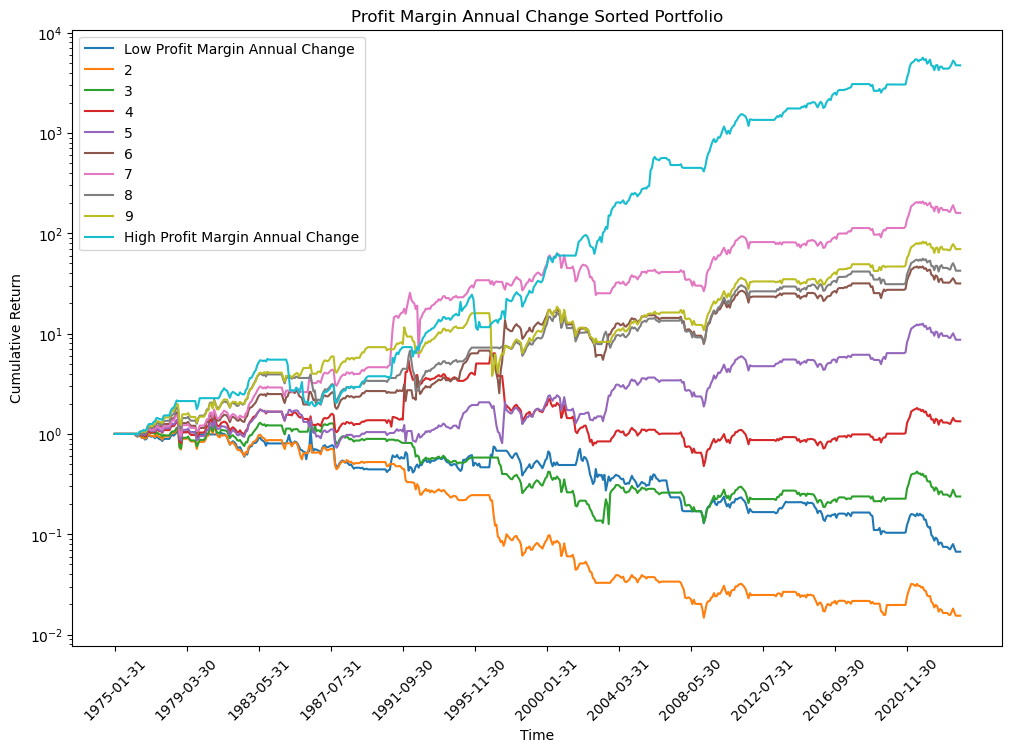

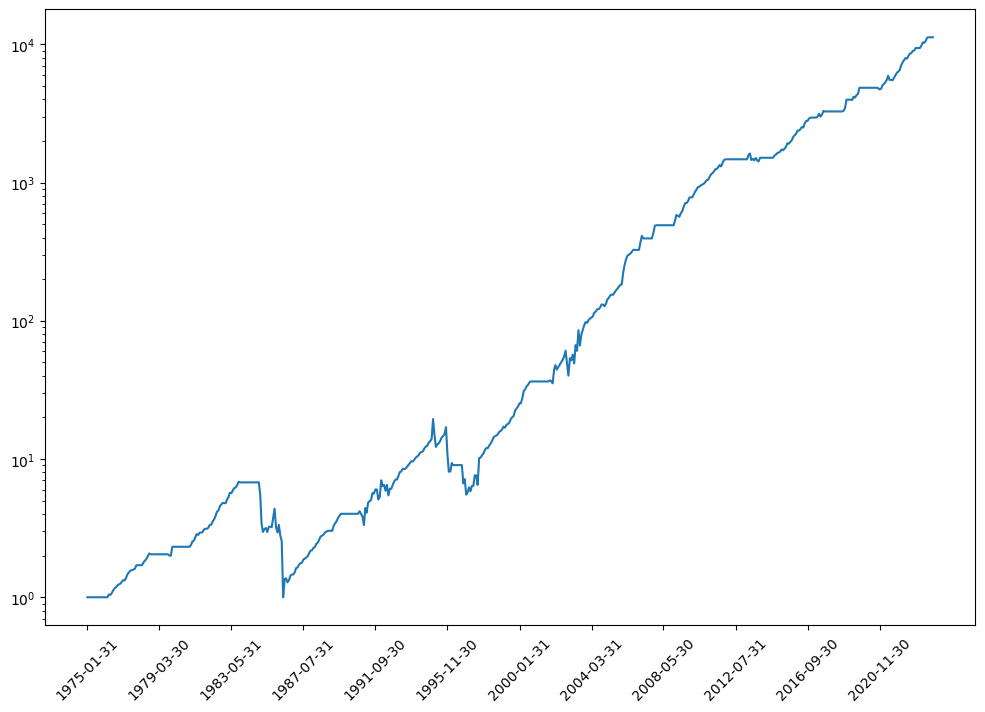

In [149]:
pm_v3 = pm.copy(deep=True)
pm_v3[~idx_Q] = np.nan
pm_v3 = pm_v3.diff(12) / pm_v3.rolling(window=24, min_periods=4).std()
pm_portfolio3 = get_sorted_portfolio(
    dfs['ret'], get_sorted_index(
        pm_v3 * get_volume_threshold(date_cusip_pivot(crsp, "vol"), 0.2),
        holding_period=3
        #,quantiles=np.array([0.2, 0.4, 0.6, 0.8])
        #,quantiles=np.array([.3, .7])
        )
)
plot_group_cum(pm_portfolio3, "Profit Margin Annual Change")
plot_solo_cum(ls(pm_portfolio3, -1, 0))